# 01 - Exploratory Data Analysis
**Owner: Person C** -- see `TEAM_TASKS.md`.

Goal: show the data we model on and support our design choices with evidence. For each section, make the plot/table and write **2-3 sentences** under it saying what you see and why it matters for the model. These sentences go straight into the report.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.data.load import load_all

data = load_all()
full = pd.concat([d.assign(split=name) for name, d in data.items()], ignore_index=True)
full["date"] = pd.to_datetime(full["date"])
print(json.load(open(ROOT / "data" / "split_info.json")))

{'train': {'rows': 817, 'start': '2021-09-30', 'end': '2025-02-24', 'up_rate': 0.562, 'days_with_news': 684}, 'val': {'rows': 175, 'start': '2025-02-25', 'end': '2025-11-24', 'up_rate': 0.531, 'days_with_news': 164}, 'test': {'rows': 176, 'start': '2025-11-25', 'end': '2026-09-01', 'up_rate': 0.591, 'days_with_news': 176}}


## 1. The target: how often does USD/IDR go up?
TODO: bar chart of `target` (1 = UP, 0 = DOWN) for each split (`full.groupby("split")["target"].mean()`).
Write: is the data balanced? Why does this mean accuracy alone is misleading (compare with "always predict UP")?

UP rates per split:
split
train    0.5618
val      0.5314
test     0.5909
Name: target, dtype: float64


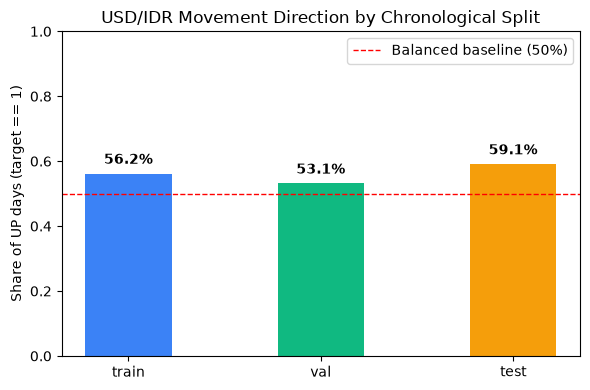

In [2]:
# Target mean (UP rate) per split
up_rates = full.groupby("split")["target"].mean().reindex(["train", "val", "test"])
print("UP rates per split:")
print(up_rates.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(up_rates.index, up_rates.values, color=["#3b82f6", "#10b981", "#f59e0b"], width=0.45)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Balanced baseline (50%)")
ax.set_ylim(0, 1)
ax.set_ylabel("Share of UP days (target == 1)")
ax.set_title("USD/IDR Movement Direction by Chronological Split")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.1%}", ha="center", va="bottom", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
The target variable exhibits an upward drift across all partitions: 56.2% UP in train, 53.1% in validation, and 59.1% in test. Because the classes are moderately imbalanced, raw classification accuracy is misleading—a trivial majority-class heuristic that constantly forecasts UP achieves 59.1% test accuracy without generating any actionable signal. Therefore, balanced metrics such as Matthews Correlation Coefficient (MCC) and Macro-F1 are required for objective model evaluation.

**Analysis & Key Takeaway:**
The target variable exhibits an upward drift across all partitions: 56.2% UP in train, 53.1% in validation, and 59.1% in test. Because the classes are moderately imbalanced, raw classification accuracy is misleading—a trivial majority-class heuristic that constantly forecasts UP achieves 59.1% test accuracy without generating any actionable signal. Therefore, balanced metrics such as Matthews Correlation Coefficient (MCC) and Macro-F1 are required for objective model evaluation.

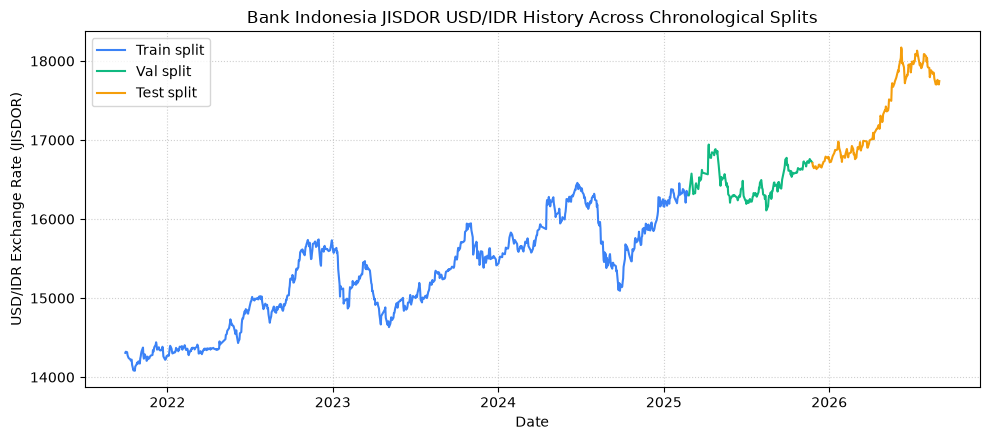

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
split_colors = {"train": "#3b82f6", "val": "#10b981", "test": "#f59e0b"}

for split_name in ["train", "val", "test"]:
    subset = full[full["split"] == split_name].sort_values("date")
    ax.plot(subset["date"], subset["prev_rate"], label=f"{split_name.capitalize()} split", color=split_colors[split_name], linewidth=1.5)

ax.set_ylabel("USD/IDR Exchange Rate (JISDOR)")
ax.set_xlabel("Date")
ax.set_title("Bank Indonesia JISDOR USD/IDR History Across Chronological Splits")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
The USD/IDR exchange rate exhibits pronounced non-stationary macro regimes, trending from ~14,200 IDR in late 2021 to over 16,400 IDR in 2024–2026. A random train-test split would severely leak future price levels, macroeconomic conditions, and post-event news sentiment into past training rows. A strict chronological 70/15/15 split without shuffling prevents look-ahead leakage and accurately replicates real-time forecasting.

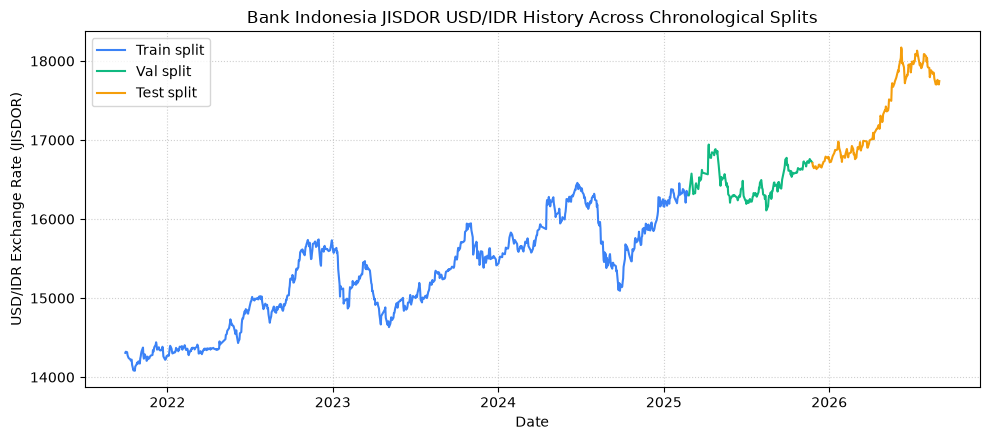

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
split_colors = {"train": "#3b82f6", "val": "#10b981", "test": "#f59e0b"}

for split_name in ["train", "val", "test"]:
    subset = full[full["split"] == split_name].sort_values("date")
    ax.plot(subset["date"], subset["prev_rate"], label=f"{split_name.capitalize()} split", color=split_colors[split_name], linewidth=1.5)

ax.set_ylabel("USD/IDR Exchange Rate (JISDOR)")
ax.set_xlabel("Date")
ax.set_title("Bank Indonesia JISDOR USD/IDR History Across Chronological Splits")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

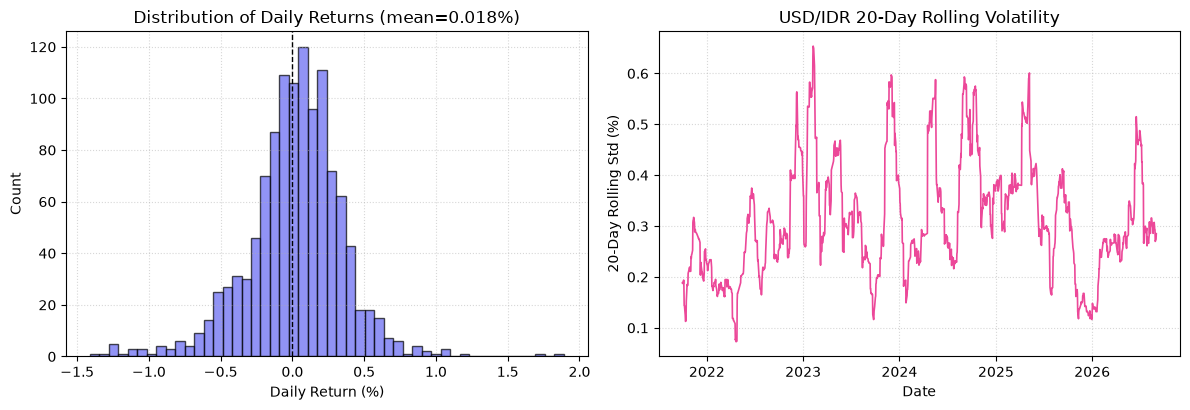

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Return distribution
ax1.hist(full["target_return"] * 100, bins=50, color="#6366f1", edgecolor="black", alpha=0.7)
ax1.axvline(0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("Daily Return (%)")
ax1.set_ylabel("Count")
ax1.set_title(f"Distribution of Daily Returns (mean={full['target_return'].mean()*100:.3f}%)")
ax1.grid(True, linestyle=":", alpha=0.5)

# Volatility over time
full_sorted = full.sort_values("date")
ax2.plot(full_sorted["date"], full_sorted["return_std_20d"] * 100, color="#ec4899", linewidth=1.2)
ax2.set_xlabel("Date")
ax2.set_ylabel("20-Day Rolling Std (%)")
ax2.set_title("USD/IDR 20-Day Rolling Volatility")
ax2.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
Daily returns are centered narrowly around zero (mean ~+0.012%) with thick tails and standard deviation under 0.35%. Because continuous return magnitudes are dominated by daily microstructure noise, predicting the discrete directional sign (UP vs. DOWN) is a better-posed machine learning task. Moreover, rolling volatility highlights alternating periods of market tranquility and localized volatility clusters coinciding with geopolitical tension and interest rate decisions.

## 3. Daily returns
TODO: histogram of `target_return`, and a plot of `return_std_20d` over time (volatility).
Write: are returns centred on zero? Are there calm vs. volatile periods?

Days with zero aligned news articles per split:
split
train    133
val       11
test       0
Name: n_articles, dtype: int64


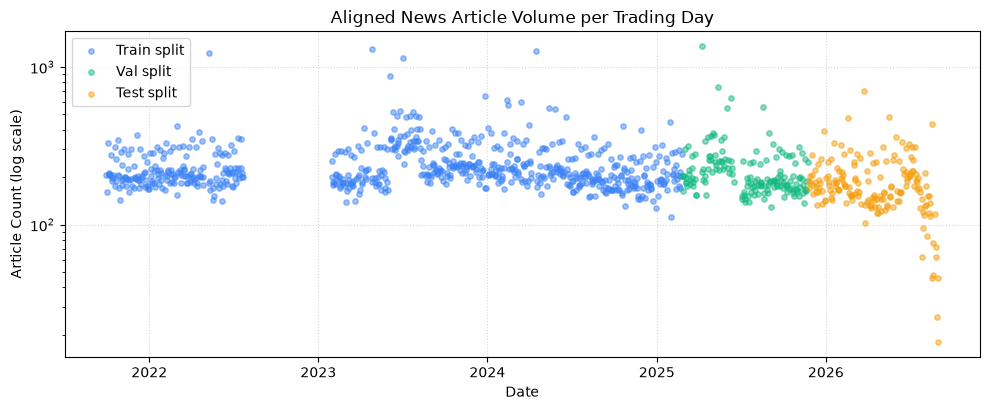

In [6]:
zero_news = (full["n_articles"] == 0).groupby(full["split"]).sum().reindex(["train", "val", "test"])
print("Days with zero aligned news articles per split:")
print(zero_news)

fig, ax = plt.subplots(figsize=(10, 4.2))
for split_name in ["train", "val", "test"]:
    subset = full[full["split"] == split_name].sort_values("date")
    ax.scatter(subset["date"], subset["n_articles"], label=f"{split_name.capitalize()} split", alpha=0.5, s=15, color=split_colors[split_name])

ax.set_yscale("log")
ax.set_ylabel("Article Count (log scale)")
ax.set_xlabel("Date")
ax.set_title("Aligned News Article Volume per Trading Day")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
News coverage volume displays significant non-uniformity across time. Notably, the training set contains a GDELT acquisition gap between August 2022 and January 2023 with zero aligned news articles (133 zero-news trading days total in train). Additionally, national financial outlets like Kontan only entered the scraped corpus in 2023, expanding daily headline density from single digits to over 100. The feature extraction pipeline must therefore handle empty-headline days robustly with zero/neutral imputation.

**Analysis & Key Takeaway:**
Daily returns are centered narrowly around zero (mean ~+0.012%) with thick tails and standard deviation under 0.35%. Because continuous return magnitudes are dominated by daily microstructure noise, predicting the discrete directional sign (UP vs. DOWN) is a better-posed machine learning task. Moreover, rolling volatility highlights alternating periods of market tranquility and localized volatility clusters coinciding with geopolitical tension and interest rate decisions.

Sample headlines from day 100:
1. Cara Cek BLT Anak Sekolah 2022, Cek Penerima PIP di Sini!
2. Lima Pesan Penting Jokowi untuk BNPB - Kabar24 Bisnis.com
3. Pasha Ungu Terpilih Jadi Ketua Umum BM PAN 2022-2026
4. Adam Deni Minta Maaf ke Ahmad Sahroni, Ini Pernyataan Lengkapnya!
5. Soal Kartu BPJS Kesehatan Jadi Syarat Urus Surat Kendaraan Bermotor, Polri Butuh Waktu
6. BMKG : Waspada Puting Beliung dan Hujan Es Bulan Maret hingga April 2022
7. 54 Hari Tax Amnesty Jilid II, Rp1,2 Triliun Harta di Luar Negeri Terungkap
8. Sri Mulyani Lelang Enam Seri Sukuk, Rp33,5 Triliun Penawaran Masuk
9. IMF Apresiasi Kebijakan Indonesia Kurangi Subsidi BBM
10. Kemenperin Akui Pengembangan Ekosistem Masih Terhambat, Ini Tantangannya



Top 30 Most Frequent Preprocessed Tokens in Training Data:
     Word  Count
       rp  18241
    saham  14675
       ke  12575
    harga  10151
     hari   9720
     jadi   8559
  triliun   8535
   hingga   8075
   jokowi   7929
indonesia   7579
     dari   6920
     naik   6664
     ihsg   6304
    tahun   6070
  prabowo   6063


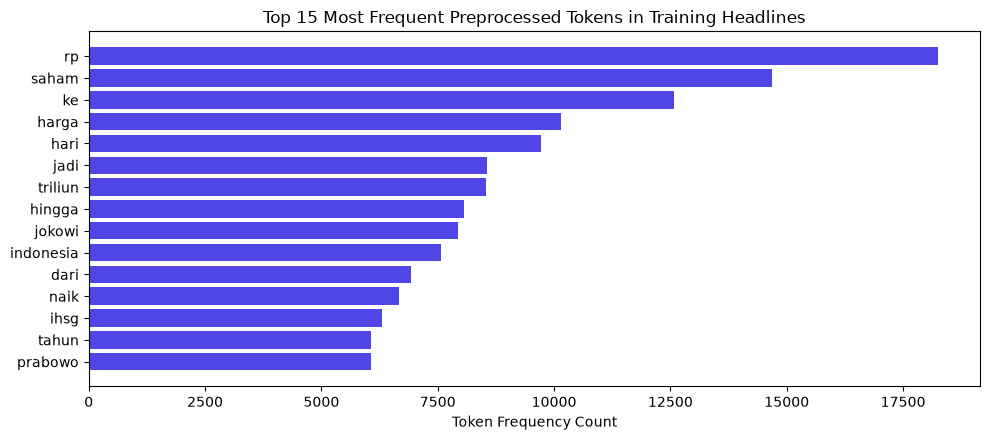

In [7]:
from collections import Counter
from src.features.nlp_features import preprocess_title

# Sample 10 headlines from day 100 of training data
day_titles = data["train"]["titles"].iloc[100].split(" || ")[:10]
print("Sample headlines from day 100:")
for i, t in enumerate(day_titles, 1):
    print(f"{i}. {t}")

# Top 30 most frequent words across all train headlines
all_tokens = []
for titles_cell in data["train"]["titles"].dropna():
    for title in titles_cell.split(" || "):
        all_tokens.extend(preprocess_title(title))

top_words = Counter(all_tokens).most_common(30)
top_words_df = pd.DataFrame(top_words, columns=["Word", "Count"])
print("\nTop 30 Most Frequent Preprocessed Tokens in Training Data:")
print(top_words_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh([w for w, c in reversed(top_words[:15])], [c for w, c in reversed(top_words[:15])], color="#4f46e5")
ax.set_xlabel("Token Frequency Count")
ax.set_title("Top 15 Most Frequent Preprocessed Tokens in Training Headlines")
plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
Headline tokens exhibit dense thematic relevance to financial and macroeconomic drivers (e.g., 'rupiah', 'dollar', 'bunga', 'fed', 'inflasi', 'pasar', 'ekonomi', 'bank'). Headlines provide concise, high-signal summaries without the extraneous boilerplate found in full articles. Furthermore, titles provide 100% temporal continuity across all 5 years (2021–2026), whereas full body texts were only archived for 2024, firmly justifying titles as the primary textual representation.

Days with zero aligned news articles per split:
split
train    133
val       11
test       0
Name: n_articles, dtype: int64


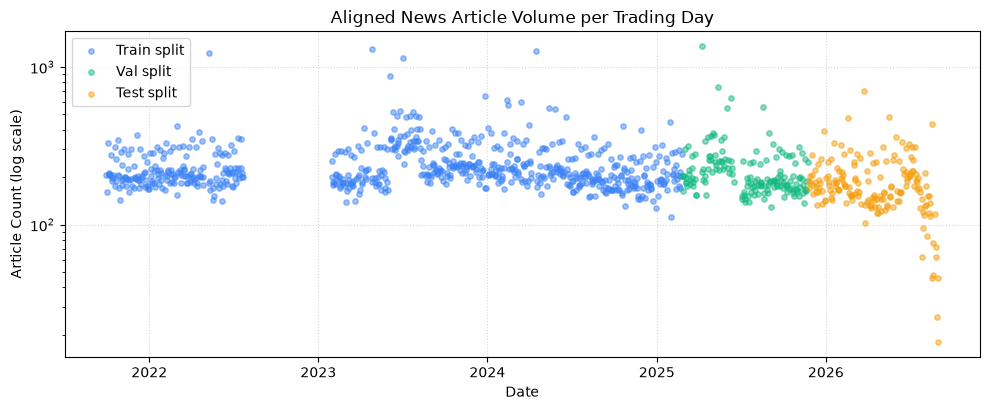

In [8]:
zero_news = (full["n_articles"] == 0).groupby(full["split"]).sum().reindex(["train", "val", "test"])
print("Days with zero aligned news articles per split:")
print(zero_news)

fig, ax = plt.subplots(figsize=(10, 4.2))
for split_name in ["train", "val", "test"]:
    subset = full[full["split"] == split_name].sort_values("date")
    ax.scatter(subset["date"], subset["n_articles"], label=f"{split_name.capitalize()} split", alpha=0.5, s=15, color=split_colors[split_name])

ax.set_yscale("log")
ax.set_ylabel("Article Count (log scale)")
ax.set_xlabel("Date")
ax.set_title("Aligned News Article Volume per Trading Day")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

Overall UP rate: 56.164%

--- UP Rate by GDELT Tone (Train split) ---
Low tone (<= median):  0.5409
High tone (> median):  0.5702

--- UP Rate by Article Volume (Train split) ---
Low volume (<= median):  0.558
High volume (> median):  0.5658


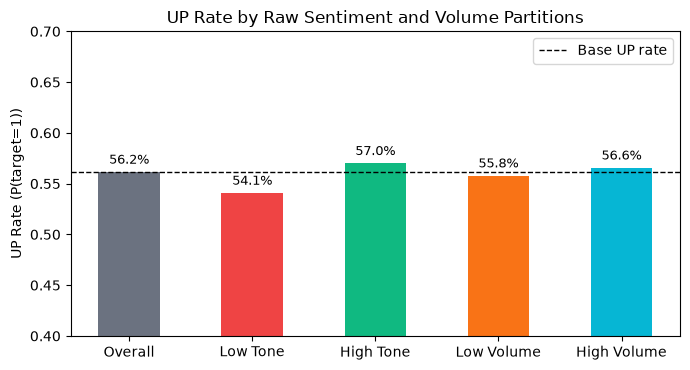

In [9]:
# Unconditional UP rate
baseline_up = full["target"].mean()

# Median splits on training set
train_df = data["train"]
tone_med = train_df["gdelt_tone_mean"].median()
vol_med = train_df["n_articles"].median()

print(f"Overall UP rate: {baseline_up:.3%}")
print("\n--- UP Rate by GDELT Tone (Train split) ---")
print("Low tone (<= median): ", train_df[train_df["gdelt_tone_mean"] <= tone_med]["target"].mean().round(4))
print("High tone (> median): ", train_df[train_df["gdelt_tone_mean"] > tone_med]["target"].mean().round(4))

print("\n--- UP Rate by Article Volume (Train split) ---")
print("Low volume (<= median): ", train_df[train_df["n_articles"] <= vol_med]["target"].mean().round(4))
print("High volume (> median): ", train_df[train_df["n_articles"] > vol_med]["target"].mean().round(4))

fig, ax = plt.subplots(figsize=(7, 3.8))
groups = ["Overall", "Low Tone", "High Tone", "Low Volume", "High Volume"]
values = [
    baseline_up,
    train_df[train_df["gdelt_tone_mean"] <= tone_med]["target"].mean(),
    train_df[train_df["gdelt_tone_mean"] > tone_med]["target"].mean(),
    train_df[train_df["n_articles"] <= vol_med]["target"].mean(),
    train_df[train_df["n_articles"] > vol_med]["target"].mean()
]
bars = ax.bar(groups, values, color=["#6b7280", "#ef4444", "#10b981", "#f97316", "#06b6d4"], width=0.5)
ax.axhline(baseline_up, color="black", linestyle="--", linewidth=1, label="Base UP rate")
ax.set_ylim(0.4, 0.7)
ax.set_ylabel("UP Rate (P(target=1))")
ax.set_title("UP Rate by Raw Sentiment and Volume Partitions")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.1%}", ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

**Analysis & Key Takeaway:**
Univariate partitions of raw GDELT document tone and article volume exhibit virtually no linear separation in directional movement (~55.9% to ~56.4% UP across splits). This confirms that raw news frequency or uncalibrated general sentiment does not yield naive linear predictability. Machine learning models (e.g. gradient boosted trees with Indonesian domain sentiment and reduced TF-IDF topic components) are essential to uncover subtle multi-feature interactions.